In [ ]:
from imblearn.ensemble import RUSBoostClassifier
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (fbeta_score, average_precision_score, precision_recall_curve, 
                             make_scorer)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from utilities.constants import IMPORTANT_FEATURES
from utilities.metrics import evaluate_model
from utilities.preprocess import preprocess_data, fillna, one_hot_encode, add_new_features, remove_top_percentile

In [2]:
datasets = {
    'train': pd.read_excel('data/Training.xlsx'),
    'test': pd.read_excel('data/Test.xlsx')
}

1. Бінарныя катэгарыяльныя класы закадуем нулямі і адзінкамі.
2. Колькасць утрыманцаў закадуем паслядоўнымі лічбамі 0, 1, 2, 3, 4. 
3. Адукацыю таксама паслядоўнымі лічбамі: 0, 1, 2. З ідэяй, што базавая адукацыя гэта меньш, чым сярэдне-спецыяльная, а сярэдне-спецыяльная і няпоўная вышэйшая гэта меньш, чым вышэйшая.

In [3]:
datasets = {
    data_type: preprocess_data(data)
    for data_type, data in datasets.items()
}

Дададзім дадатковыя прыкметы:
1. has_dependents: ці ёсць утрыманцы
2. H_bigger_than_zero: ці вышэй за нуль прыкмета 'H'
3. is_single: ці з'яўляецца чалавек адзінокім

In [4]:
datasets = {
    data_type: add_new_features(data)
    for data_type, data in datasets.items()
}

In [5]:
features = {
    data_type: data.drop(columns=['target'])
    for data_type, data in datasets.items()
}

targets = {
    data_type: data['target']
    for data_type, data in datasets.items()
}

Запоўнім прапушчанныя значэнні: для безперапынных прыкмет медыяная размеркавання, для катэгарыяльных - модай.

In [6]:
processed_features = fillna(features)

Закадуем небінарныя катэгарыяльныя пераменныя праз one-hot-encoding.

In [7]:
processed_features = {
    data_type: one_hot_encode(data)
    for data_type, data in processed_features.items()
}

In [8]:
processed_features = {
    data_type: data[IMPORTANT_FEATURES].copy()
    for data_type, data in processed_features.items()
}

Для вырашэння задачы выкарыстаю наступныя алгарытмы:
1. Лагістычная рэгрэсія
2. Выпадковы лес
3. Rusboost - бустынг-алгарытм з убудаваным андэрсамплінгам для паляпшэння вынікаў для задач з несбалансаванымі класамі

Ажыцявім пошук аптымальных гіперпараметраў, для лагістычнай рэгрэсіі пошукам па сетцы. Для астатніх выпадковым пошукам. 

У якасці параметра ацэнкі выкарыстаем f2-меру.

In [9]:
ftwo_scorer = make_scorer(fbeta_score, beta=2)

In [10]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": ['balanced', {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 50}, {0: 1, 1: 75}]
}

grid = GridSearchCV(
    LogisticRegression(class_weight="balanced"),
    param_grid,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

scaler = StandardScaler()

grid.fit(scaler.fit_transform(processed_features['train']), targets['train'])

grid.best_estimator_

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1, 1: 50}"
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good de

In [11]:
param_grid_rf = {
    "n_estimators": [50, 100, 200, 300, 400, 600, 800],
    "max_depth": [5, 10, 20, 30, 50, 100, 200, None],
    "min_samples_leaf": [20, 30, 40, 50, 80, 100],
    "max_features": ["sqrt", "log2"],
    "class_weight": ['balanced_subsample', {0: 1, 1: 50}, {0: 1, 1: 75}, {0: 1, 1: 100}, {0: 1, 1: 150}, {0: 1, 1: 200}, {0: 1, 1: 250}]
}

grid = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample"),
    param_grid_rf,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 1, 1: 150}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-firs

In [13]:
param_grid_rus = {
    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "estimator__max_depth": [2, 3, 5, 10, 20],
    "estimator__min_samples_leaf": [1, 2, 3, 5, 10]
}

grid = RandomizedSearchCV(
    RUSBoostClassifier(
        estimator=DecisionTreeClassifier(
            random_state=42
        ),
        random_state=42
    ),
    param_grid_rus,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,600
,learning_rate,0.05
,random_state,42
,algorithm,'deprecated'
,sampling_strategy,'auto'
,replacement,False
Name,Type,Value
base_sampler_,RandomUnderSampler,RandomUnderSampler()
classes_,"ndarray[int64](2,)","[0,1]"
estimator_,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)


In [28]:
param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),            
    'colsample_bytree': uniform(0.6, 0.4), 
    'gamma': uniform(0, 5),
    'reg_lambda': uniform(0.5, 5),
    'scale_pos_weight': [20, 50, 100, 150, 200, 250]
}

grid = RandomizedSearchCV(
    XGBClassifier(
        random_state=42
    ),
    param_dist,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.9387974396959335)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Алгарытмы на базе дрэваў рашэнняў дапоўнім калібратарам сігмоіды, для карэктнай інтэрпрэтацыі выхаду мадэляў як імавернасці.

In [30]:
models = {
    "Logistic Regression": 
    Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight={0: 1, 1: 50},
                C=0.01,
                max_iter=1000,
                random_state=42
            )
        )
    ]),   
    "Random Forest": 
    CalibratedClassifierCV(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=100,
            min_samples_leaf=50,
            max_features="log2",
            class_weight={0: 1, 1: 200},
            random_state=42,
            n_jobs=-1
        ),
        method="sigmoid",
        cv=5
    ),

    "RUSBoost": 
    CalibratedClassifierCV(
        RUSBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=2,
                random_state=42
            ),
            learning_rate=0.05,
            n_estimators=400,
            random_state=42,
        ),
        method="sigmoid",
        cv=5
    ),
    "XGBoost":
    CalibratedClassifierCV(
        XGBClassifier(
            objective='binary:logistic',
            n_estimators=236,
            learning_rate=0.035,
            max_depth=4,
            colsample_bytree=0.94,
            gamma=1.33,
            scale_pos_weight=100,
            random_state=42,
            eval_metric='logloss',
            reg_lambda=0.7,
            subsample=0.9
        )
    )
}

Для вызначэння найлепшай мадэлі ажыцявім крос-валідацыю на 5 фалдах.
На кожнай ітэрацыі:
1. Чатыры фалда выкарыстоўваюцца як трэніровачная выбарка, а пяты як валідацыйная.
2. Адбываецца запаўненне прапушчаных значэнняў, падбор шкаліроўшчыка і навучанне мадэляў толькі на трэніровачных фалдах.
3. Падбіраецца аптымальны парог (па максімізацыі f2-меры) толькі для цяперашняй ітэрацыі для раздзялення па мэтавым класам.
4. Збіраюцца прадказанні мадэляў па розным фалдам.
Пасля цыкла па прадказанням сярод усіх фалдоў разлічваюцца метрыкі і падбіраецца парог, які будзе выкарыстоўвацца фінальнай мадэллю.

In [31]:
results = []
best_thresholds = {}

cross_validation_folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for model_name, model in models.items():
    split_positions = cross_validation_folds.split(features['train'], targets['train'])

    probabilities = []
    actuals = []
    predictions = []

    for train_idx, valid_idx in split_positions:
        X_train = features['train'].iloc[train_idx]
        X_valid = features['train'].iloc[valid_idx]

        y_train = targets['train'].iloc[train_idx]
        y_valid = targets['train'].iloc[valid_idx]

        X_train = add_new_features(X_train)
        X_valid = add_new_features(X_valid)

        X_train = fillna({'train': X_train, 'test': X_valid})['train']
        X_valid = fillna({'train': X_train, 'test': X_valid})['test']

        X_train = one_hot_encode(X_train)
        X_valid = one_hot_encode(X_valid)

        X_train = X_train[IMPORTANT_FEATURES].copy()
        X_valid = X_valid[IMPORTANT_FEATURES].copy()

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_valid)[:, 1]

        precision, recall, thresholds = precision_recall_curve(
            y_valid,
            y_prob
        )

        f2_scores = (
            5 * precision[:-1] * recall[:-1]
        ) / (
            4 * precision[:-1] + recall[:-1] + 1e-10
        )

        threshold = thresholds[np.argmax(f2_scores)]
        y_pred = (y_prob >= threshold).astype(int)

        probabilities = probabilities + y_prob.tolist()
        actuals = actuals + y_valid.tolist()
        predictions = predictions + y_pred.tolist()   

    precision, recall, thresholds = precision_recall_curve(
        actuals,
        probabilities
    )

    f2_scores = (
        5 * precision[:-1] * recall[:-1]
    ) / (
        4 * precision[:-1] + recall[:-1] + 1e-10
    )

    best_thresholds[model_name] = thresholds[np.argmax(f2_scores)]

    results.append({
        "model": model_name,
        "PR_AUC": average_precision_score(
            actuals,
            probabilities
        ),
        "F2": fbeta_score(
            actuals,
            predictions,
            beta=2
        ),
        "threshold": best_thresholds[model_name]
    })         
        

In [32]:
results = pd.DataFrame(results)
results

,model,PR_AUC,F2,threshold
0,Logistic Regression,0.040429,0.161503,0.615794
1,Random Forest,0.041561,0.157410,0.028878
2,RUSBoost,0.039711,0.184796,0.033632
3,XGBoost,0.042007,0.164902,0.036244


Лепшая мадэль вызначаецца па самай вялікай f2-меры сярод усіх фалдоў.

Гэта мадэль навучаецца на ўсёй трэніровачнай выбарцы, у якасці парога выкарыстоўваецца значэнне падабранае падчас крос-валідацыі.

In [33]:
selection_metric = 'F2'
best_model = results[results[selection_metric] == results[selection_metric].max()]['model'].iloc[0]

final_model = models[best_model]
    
final_model.fit(processed_features['train'], targets['train'])

y_prob = final_model.predict_proba(processed_features['test'])[:, 1]

y_pred = (y_prob >= best_thresholds[best_model]).astype(int)
best_model

'RUSBoost'

F2 Score: 0.1789
Average Precision: 0.0242
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     38259
           1       0.06      0.38      0.10       146

    accuracy                           0.97     38405
   macro avg       0.53      0.68      0.54     38405
weighted avg       0.99      0.97      0.98     38405



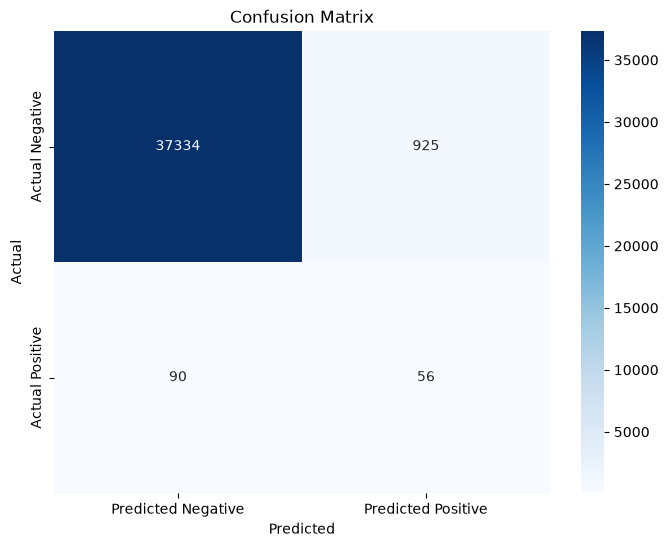

In [34]:
evaluate_model(targets['test'], y_pred)

Мадэль можна даналадзіць, у выпадку, калі патрэбна прапусціць вялікую колькасць кліентаў і адкінуць толькі самых рызыкоўных, або наадварот: зрабіць вельмі асцярожную і пераборлівую мадэль з мінімальнай колькасцю нераспазнаных дэфолтаў.